# 04. Feature Engineering, Model Benchmarks & ROC Evaluation
Evaluate LightGBM, XGBoost, CatBoost, and Logistic Regression models using engineered F1 features, and plot ROC curves across all models.


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
sys.path.insert(0, str(Path.cwd().parent))
from src.train import run_pipeline


In [2]:
# Run 5-fold CV training pipeline across models
results = run_pipeline(n_splits=5, save_submission=False)


Starting F1 Pit Stop Prediction Training Pipeline

[1/5] Loading raw data...


Train shape: (439140, 16), Test shape: (188165, 15)

[2/5] Engineering features...


Total features created: 26

[3/5] Setting up 5-fold StratifiedGroupKFold validation by EventID...



[4/5] Training models across folds...

--- Fold 1/5 ---


  LogisticRegression ROC-AUC: 0.85013


...

  LightGBM           ROC-AUC: 0.91318


  XGBoost            ROC-AUC: 0.91556


  CatBoost           ROC-AUC: 0.91150

OUT-OF-FOLD (OOF) EVALUATION RESULTS
LogisticRegression   | ROC-AUC: 0.82695 | LogLoss: 0.38864 | PR-AUC: 0.50320


LightGBM             | ROC-AUC: 0.93154 | LogLoss: 0.25897 | PR-AUC: 0.73527
XGBoost              | ROC-AUC: 0.93238 | LogLoss: 0.25753 | PR-AUC: 0.73909


CatBoost             | ROC-AUC: 0.93044 | LogLoss: 0.26095 | PR-AUC: 0.73403
WeightedEnsemble     | ROC-AUC: 0.93193 | LogLoss: 0.25909 | PR-AUC: 0.73857


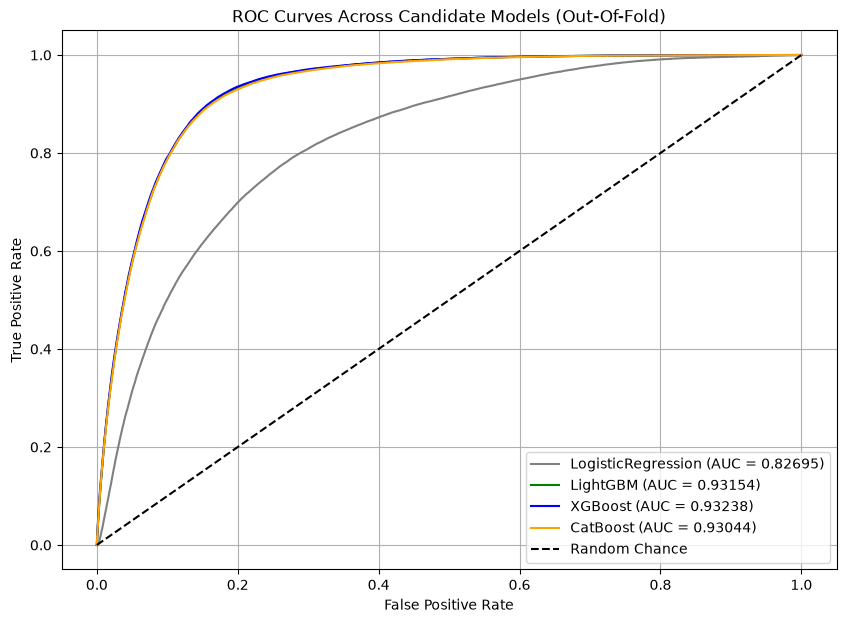

In [3]:
oof_preds = results['oof_predictions']
from src.data import load_raw_data
train, _, _ = load_raw_data('../data/raw')
y_true = train['PitNextLap'].values

# Plot ROC Curves
plt.figure(figsize=(10, 7))
colors = {'LogisticRegression': 'gray', 'LightGBM': 'green', 'XGBoost': 'blue', 'CatBoost': 'orange'}
for mname, preds in oof_preds.items():
    fpr, tpr, _ = roc_curve(y_true, preds)
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{mname} (AUC = {score:.5f})', color=colors.get(mname, 'red'))
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Across Candidate Models (Out-Of-Fold)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
